In [5]:
#todo:
#scatter i.e. fission single neutron
#find kriticality equilibrium
#re-up the neutron count when depleted/excessed

#properly plot fluxes
#fit theoretical fluxes
    #p.229 from James J. Duderstadt


import numpy as np
import matplotlib.pyplot as plt
import random as random




In [6]:
def path_len(N,sigma=0.7):
    """
    gives the pathlength given a number of neutrons, cross-section
    input:
    N, nnumber of neutrons, int
    sigma, cross-section, float
    return:
    path_len, length of path of neutrons, array[N]
    """
    
    
    return -np.log(np.random.uniform(0,1,N))/sigma

    
def check_vol_cil(P,H,R):
    """""
    checks wether a point is in a cilinder
    input:
    P, points, arrray
    H, heigth of cilinder, float
    R, radius, float
    return:
    B, boolean array
        
    """
    x=np.array(P[:,0])
    y=np.array(P[:,1])
    z=np.array(P[:,2])
    r_2=x**2+y**2
    B1=r_2<R**2
    B2=z>-H/2
    B3=z<H/2
    return B1*B2*B3
    
def check_vol_sph(P,R):
    """""
    checks wether a point is in a sphere
    input:
    P, points, arrray
    R, radius, float
    return:
    B, boolean array
    """
    x=np.array(P[:,0])
    y=np.array(P[:,1])
    z=np.array(P[:,2])
    r_2=x**2+y**2+z**2
    return r_2<R**2


def check_vol_slab(P,T, L_max=1):
    """""
    checks wether a point is in a infinite slab
    input:
    P, points, arrray
    T, Thickness, float
    L_max, reoccuring boundary
    return:
    B, boolean array
    P, points of neutrons
    """
    B=np.abs(np.array(P[:,0]))<T 
    P[:,1]=np.array(P[:,1])%L_max
    P[:,2]=np.array(P[:,2])%L_max

    return B, P

def check_vol_box(P,lx=1,ly=1,lz=1):
    """""
    checks wether a point is in a infinite slab
    input:
    P, points, arrray
    T, Thickness, float
    L_max, reoccuring boundary
    return:
    B, boolean array
    P, points of neutrons
    """
    Bx=np.abs(np.array(P[:,0]))<lx
    By=np.abs(np.array(P[:,1]))<ly
    Bz=np.abs(np.array(P[:,2]))<lz

    B=Bx*By*Bz
    return B

def rand_dir2(N,sigma=0.7):
    """ gives N random paths in D[N,Dim]
    inpit:
    N, number of neutrons, int
    sigma, cross-section, float
    output:
    D, distance of path, 3d array[N,Dim] 
    """
    D=np.zeros([N,3])
    x=np.array(np.random.uniform(-1,1,N))
    y=np.array(np.random.uniform(-1,1,N))
    z=np.array(np.random.uniform(-1,1,N))
    r_2=x**2+y**2+z**2
    r=np.sqrt(r_2)
    p_len=path_len(N,sigma)
    D[:,0]=p_len*x/r   # pathlength * to x component
    D[:,1]=y/r*p_len
    D[:,2]=z/r*p_len
    return D

def fission(N):
    """gives on average 2.43 neutrons, either 2 or 3, array like N"""
    n=np.random.uniform(0,1,N)
    N=2+(n<.43)
    return N


def start(N,R):
    """Gives positions in a P[N,Dim] array"""
    x=np.array(np.random.uniform(-1,1,N))*R
    y=np.array(np.random.uniform(-1,1,N))*R
    z=np.array(np.random.uniform(-1,1,N))*R
    P=np.zeros([N,3])
    P[:,0]=x
    P[:,1]=y
    P[:,2]=z
    return P


def plots(counter, K_counter,P, title="", Hist=False):

    plt.plot(counter)
    plt.xlabel("generation")
    plt.ylabel("number of neutrons")
    plt.title(title)
    
    plt.show()
    plt.plot(K_counter)
    plt.xlabel("generation")
    plt.ylabel("k factor")
    print("mean K =",np.mean(K_counter))
    plt.show()
    if Hist==True:
        plt.hist(P[:,0],bins=100);
        plt.xlabel("x")
        plt.ylabel("flux density")
    return



def kernel(N,Sigma_c=0.2,Sigma_f=0.5):
    """gives a list of fusion, 0 for capture"""
    R=np.random.uniform(0,Sigma_c+Sigma_f,N)
    
    return (R>Sigma_c)*fission(N)


def kernel2(N,Sigma_c=0.2,Sigma_f=0.5, Sigma_s=0):
    """gives a list of fusion, 0 for capture"""
    R=np.random.uniform(0,Sigma_c+Sigma_f+Sigma_s,N)
    
    return (R>Sigma_c)*(R<Sigma_c+Sigma_f)*fission(N) + (R>Sigma_c+Sigma_f)*np.ones(N)







In [7]:
def nuclear_flux_sim_v2(I=1000,N=10000, max_N= 100000, shape="sphere",R=1.81, H=2.61,L_max=1,T=1, lx=1.51, ly=1.51, lz=1.51, Sigma_c=0.2,Sigma_f=0.5):
    
    """""
    function to simulate the one-speed, homogenous, convex nuclear core.
    Input:
    I                 : int:    maximum number of iterations
    N                 : int:    number of neutrons at the start
    max_N             : int:    maximum allowed neutrons till simulation termination
    Shape             : string: shape of the core, chose from sphere, slab, cube, cilinder  
    R,H,L_max,lx,ly,lz: float : dimensions of the shapes above
    sigma_c, sigma_f  : float : crossesction of capture and fission
    """""    
    
    
    
    
    
    P=start(N,1) # postions,insert number and radius of a sphere, produces P[N,dim]
    counter=[]  # counts number of neutrons
    K_counter=[] # keeps track of the k-factor
    Sigma_s=0  # just a work in progress for scattering
       
    
    for i in range(I):
        print(f' {(i)/I*100:.0f}%' , end='\r')
        N_i=len(P)
        N=len(P)
        P= P + rand_dir2(N, sigma=Sigma_c+Sigma_f+Sigma_s) # add a path to all the positions
        
        
        
        if shape=="sphere":
            B=check_vol_sph(P,R) # check for neutrons to be outside after adding the path
        if shape =="cilinder":
            B=check_vol_cil(P,H,R) 
        if shape== "slab":
            B, P= check_vol_slab(P,T,L_max)
        if shape== "box":
            B= check_vol_box(P,lx,ly,lz)
               
        P=P[B] # ditch all the outside neutrons
        
        F_list=kernel2(len(P), Sigma_c=Sigma_c,Sigma_f=Sigma_f, Sigma_s=Sigma_s) # list of neutron produces either 0,2,3; 0== capture
        B_scat=(F_list>0.5) * (F_list<1.5)
        B_fus=F_list>1.5
        B_fus2=F_list>2.5 # select some boolean to pick neutrons that produced a third neutron
        P_i=P[B_fus]
        P_ii=P[B_fus2]
        P2=np.concatenate((P_i,P_i,P_ii),axis=0) # new positions are the positions that created fusion 2X and some that created a fusion with 3 neutrons
        
        c=len(P[:,0])
        counter.append(c)
        N_o=len(P2)
        
        if N_i==0:
            print('oof')
            break
        if N_i>max_N:
            print('boem!')
            break
            
        k=N_o/N_i
        K_counter.append(k)
        P=P2 # replace initial positions with new position
    return counter, K_counter, P





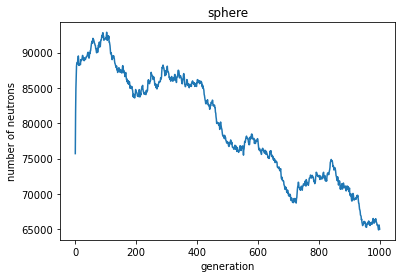

mean K = 1.0000051176343143


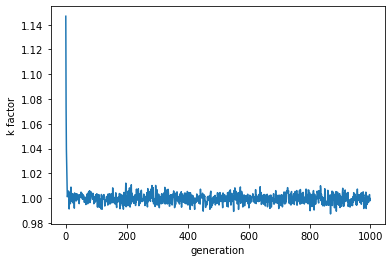

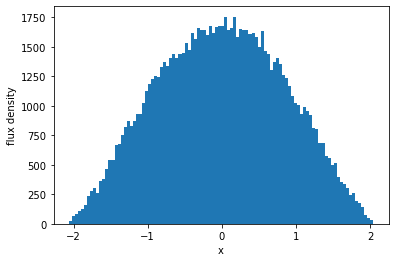

In [8]:
counter, K_counter,P =nuclear_flux_sim_v2(I=1000,N=100000, R=2.07,  Sigma_c=0.305,Sigma_f=0.5, max_N=1000000)
plots(counter, K_counter,P, title="sphere", Hist=True)
plt.show()

#counter, K_counter,P =nuclear_flux_sim_v2(I=1000,N=30000, shape="box")
#plots(counter, K_counter,P,title="cube")
#plt.show()

#counter, K_counter,P =nuclear_flux_sim_v2(I=1000,N=30000, shape="slab",T=.65)
#plots(counter, K_counter,P, title="slab")
#plt.show()

#counter, K_counter,P =nuclear_flux_sim_v2(I=1000,N=50000, shape="cilinder", H=2.62)
#plots(counter, K_counter,P, title="cilinder")
